# comparing runtimes of the particle to full models
Tim Tyree<br>
6.6.2025

In [3]:
import sys,os
og_stdout=sys.stdout
from lib.my_initialization import *
os.chdir(nb_dir)
from lib import *
# import cupy, cudf
# from lib.rapids_func import *
import seaborn as sns
import matplotlib.ticker as mtick
import warnings
warnings.simplefilter("ignore", UserWarning)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import seaborn as sns
#reset matplotlib
plt.plot([1]*4)
plt.close()
#reset matplotlib settings
import matplotlib as mpl
sns.reset_orig()
mpl.rc_file_defaults()

# define module

In [980]:
#heretimheretim
@njit
def one_step_particle_fast(N,still_running,x_old,y_old,x_new,y_new,
                      L,impulse_prefactor,force_code,no_repulsion,no_attraction,
                       Fx_net,Fy_net,epsilon,caught,anticaught,stepscale,A,
                           use_creation,zeros,use_pair_create,probreact,x0,
                           tiarray,tfarray,varkappa,D,t,exit_code,R_c_bar,
                     ):
    """
    Example Usage:
retval = one_step_particle_fast(N,still_running,x_old,y_old,x_new,y_new,
                      L,impulse_prefactor,force_code,no_repulsion,no_attraction,
                       Fx_net,Fy_net,epsilon,caught,anticaught,stepscale,A,
                           use_creation,zeros,use_pair_create,probreact,x0,
                           tiarray,tfarray,varkappa,D,t,exit_code,R_c_bar,
                     )
still_running,x_old,y_old,x_new,y_new,Fx_net,Fy_net,caught,anticaught,tiarray,tfarray,exit_code = retval
    """
    #######################################################
    #sum_each_force_kernel
    for i in range(N):
        if(still_running[i]):
            for j in range(i+1,N):
                if(still_running[j]):
                    #compute displacement vector with pbc
                    dx = subtract_pbc_1d(x_old[j],x_old[i],L);
                    dy = subtract_pbc_1d(y_old[j],y_old[i],L);
                    dist2=dx*dx+dy*dy;
                    if (dist2<1e-8):
                        dist2=float(1e-8)
                    dist = np.sqrt(dist2)
                    #compute displacement due to drift
                    impulse_factor=0.
                    if (force_code==1):
                      #spring
                      impulse_factor=impulse_prefactor*(dist-x0)/dist;
                    if (force_code==2):
                      #QED2: force ~ inverse power law
                      impulse_factor=impulse_prefactor/dist2;
                    if (force_code==3):
                      #QED3: force ~ inverse square power law
                      impulse_factor=impulse_prefactor/dist2/dist;
                    #set impulse_factor to zero if it is explicitly forbidden by the user input
                    if ((no_attraction==1) & (impulse_factor>0)):
                        impulse_factor=0.
                    if ((no_repulsion==1) & (impulse_factor<0)):
                        impulse_factor=0.
                    #sum Fx_net, Fy_net according to a symplectic (momentum conserving) integrator
                    Fx_net[i]=Fx_net[i]+dx*impulse_factor;
                    Fy_net[i]=Fy_net[i]+dy*impulse_factor;
                    Fx_net[j]=Fx_net[j]-dx*impulse_factor;
                    Fy_net[j]=Fy_net[j]-dy*impulse_factor
                    #determine if they are closer than epsilon
                    if dist<epsilon:
                        #remove if they are
                        still_running[i]=False
                        still_running[j]=False
                        uncatch_set=set()
                        if caught[i]>=0:
                            uncatch_set.update([caught[i]])
                            if caught[caught[i]]>=0:
                                uncatch_set.update([caught[caught[i]]])
                        if caught[j]>=0:
                            uncatch_set.update([caught[j]])
                            if caught[caught[j]]>=0:
                                uncatch_set.update([caught[caught[j]]])
                        if len(uncatch_set)>0:
                            for k in uncatch_set:
                                caught[k]=-9999
    #compute the one_step given the net force, F_net
    for i in range(N):
        if(still_running[i]):
            if caught[i]<0:
                dxt=Fx_net[i];
                dyt=Fy_net[i];
                # compute displacement due to levy flight
#                 dxW,dyW = stepscale*levyRandom2D(alpha)
#                     dxW = stepscale*normalRandom()
#                     dyW = stepscale*normalRandom()
                dxW = stepscale*np.random.normal()
                dyW = stepscale*np.random.normal()
                # next spatial position, time integrating by a duration, Dt. enforce PBC.
                x_new[i]=periodic(x_old[i]+dxW+dxt,L);
                y_new[i]=periodic(y_old[i]+dyW+dyt,L);
            else:
                j=caught[i]
                ti=tiarray[i]
                tf=tfarray[i]
                #compute displacement vector with pbc
                dx = subtract_pbc_1d(x_old[j],x_old[i],L)
                dy = subtract_pbc_1d(y_old[j],y_old[i],L)
                xl = dx - (x_old[j]-x_old[i])
                yl = dy - (y_old[j]-y_old[i])
                #compute average location
                xavg = x_old[i] + 0.5*dx
                yavg = y_old[i] + 0.5*dy
                #compute frac to interpolate by
                frac = (t-ti)/(tf-ti)
#                     frac = np.min((1.,frac))
                frac = min((1.,frac))
                x_new[i] = periodic(x_old[i]*(1.-frac) + (xavg+xl)*frac,L)
                y_new[i] = periodic(y_old[i]*(1.-frac) + (yavg+yl)*frac,L)
    #reaction_kernel
    for i in range(N):
        if(still_running[i]&(caught[i]<0)&(anticaught[i]<0)):
            # // each i,j pair is reached once per call to kernel_measure
            for j in range(i+1,N):
                if(still_running[j]&(caught[j]<0)&(anticaught[j]<0)):
                    # // compute distance between particles that are still running
                    dist=dist_pbc(x_new[i],y_new[i],x_new[j],y_new[j],L);
                    in_range=dist<r;
                    # // in_range=true;//uncomment for smeared method
                    # // if two particles are in range
                    if(in_range):
                        # // determine whether those two particles react via the simple method
#                             reacts=probreact>uniformRandom();
                        reacts=probreact>np.random.uniform(0,1);
                        # // determine whether those two particles react via the smeared method
                        # // sig=sigmoid(dist, r, beta);
                        # // reacts=probreact*sig>uniformRandom();
                        if(reacts):
                            exit_code=1;
                            T=t;
#                             still_running[i]=False;
#                             still_running[j]=False;
                            #uncatch any previous catches
                            if caught[i]>=0: caught[caught[i]]=-9999
                            if caught[j]>=0: caught[caught[j]]=-9999
                            #catch these two
                            caught[i]=j;
                            caught[j]=i;
                            #determine deltat
                            deltat = dist**2/(4*(varkappa+2*D))
                            #determine ti,tf
                            tiarray[i]=t
                            tfarray[i]=t+deltat
                            tiarray[j]=t
                            tfarray[j]=t+deltat

    #determine rate_of_creation from average density
    num_particles = np.sum(still_running)
    prob_create = dt * Mp * (num_particles / A) ** nup * A
    #creation_kernel
    if not use_creation:
        prob_create=0
    if prob_create>np.random.uniform(0,1):
        if np.sum(~still_running)>=2:
            #select the first two particles that are removed
            igone=np.argwhere(~still_running)
            #reset/set their internal state
            caught[igone[0]]=-9999
            caught[igone[1]]=-9999
            anticaught[igone[0]]=igone[1]
            anticaught[igone[1]]=igone[0]
            tfarray[igone[0]]=t+creation_duration
            tfarray[igone[1]]=t+creation_duration

#                 #set their positions to 2 uniformly distributed positions
#                 x_new[igone[0]]=np.random.uniform(0,1)*L
#                 x_new[igone[1]]=np.random.uniform(0,1)*L
#                 y_new[igone[0]]=np.random.uniform(0,1)*L
#                 y_new[igone[1]]=np.random.uniform(0,1)*L

            #check if new particle is within distance R_c_bar from any other particles
            for ihere in igone[:2]:
                xg,yg=seed_new_particle(x_new,y_new,still_running,L,R_c_bar,max_num_retries=1000)
                x_new[ihere]=xg
                y_new[ihere]=yg
                still_running[ihere]=True

            #optionally set their positions to average a random location
            if use_pair_create:
#                     #optionally set their positions be a fixed distance to nearest tip
#                     if use_set_created_from_existing:
#                         #place a pair of particles uniformly on the circle of radius R_c_bar from a random particle
#                         xg,yg=gener_random_creation_position(x_new,y_new,still_running,R_c_bar,L)
#                         x_new[igone[0]] = xg
#                         y_new[igone[0]] = yg
                theta=2*np.pi*np.random.uniform(0,1)
                #heretim
                x_new[igone[1]]=x_new[igone[0]] + 2.*r0*np.cos(theta)
                y_new[igone[1]]=y_new[igone[0]] + 2.*r0*np.sin(theta)


    # reset the net forces
    Fx_net=zeros.copy()
    Fy_net=zeros.copy()
    #creation_force_kernel
    if use_pair_create:
        for i in range(N):
            if(still_running[i]&(anticaught[i]>=0)):
                j = anticaught[i]
                if still_running[j]:
                    #compute displacement vector with pbc
                    dx = subtract_pbc_1d(x_old[j],x_old[i],L);
                    dy = subtract_pbc_1d(y_old[j],y_old[i],L);
                    dist2=dx*dx+dy*dy;
                    if (dist2<1e-8):
                        dist2=float(1e-8)
                    dist = np.sqrt(dist2)
                    #compute displacement due to drift
                    impulse_factor=0.
                    if (force_code==1):
                      #spring
                      impulse_factor=impulse_prefactor*(dist-x0)/dist;
                    if (force_code==2):
                      #QED2: force ~ inverse power law
                      impulse_factor=impulse_prefactor/dist2;
                    if (force_code==3):
                      #QED3: force ~ inverse square power law
                      impulse_factor=impulse_prefactor/dist2/dist;
                    #set impulse_factor to zero if it is explicitly forbidden by the user input
                    if ((no_attraction==1) & (impulse_factor<0)):
                        impulse_factor=0.
                    if ((no_repulsion==1) & (impulse_factor>0)):
                        impulse_factor=0.
                    #account for double counting and then scale
                    impulse_factor*=0.5*chi
                    #sum Fx_net, Fy_net according to a symplectic (momentum conserving) integrator
                    Fx_net[i]=Fx_net[i]-dx*impulse_factor;
                    Fy_net[i]=Fy_net[i]-dy*impulse_factor;
                    Fx_net[j]=Fx_net[j]+dx*impulse_factor;
                    Fy_net[j]=Fy_net[j]+dy*impulse_factor

    #turn off creation array
    for i in range(N):
        if still_running[i] and anticaught[i]>=0:
            if t>tfarray[i]:
                anticaught[i]=-9999
    #############################################################
#     return None
    return still_running,x_old,y_old,x_new,y_new,Fx_net,Fy_net,caught,anticaught,tiarray,tfarray,exit_code

In [981]:
# one_step_particle_fast

In [1009]:
# @njit
def format_particles(frameno,t,x_values,y_values,pid_values,round_t_to_n_decimals=5,tscale=1000):
    '''tscale scales from seconds to milliseconds.
    round_t_to_n_decimals=5 corrects arithmatic error, minimizes output memory requirements, and matches Dt=dt=1e-5 seconds
    '''
    n_tips = x_values.shape[0]
    dict_out = {
        'frame':frameno,
        't': np.around(t,round_t_to_n_decimals)*tscale,
        'n': n_tips,
        'x': x_values,
        'y': y_values,
        'pid_explicit':pid_values}
    return dict_out

import numpy as np, pandas as pd, os, sys
# from numba import njit

@njit
def sqdiff(x1, x2):
    return pow((x1-x2),2)

@njit
def min3(num1, num2, num3):
    if (num1 > num2 ):
        mn=num2
    else:
        mn=num1
    if (mn>num3):
        mn=num3
    return mn

@njit
def dist_pbc(x1, y1, x2, y2, L):
    # returns the smallest dist of each possible pbc combination
    xsq1 = sqdiff(x1,x2)
    xsq2 = sqdiff(x1,x2+L)
    xsq3 = sqdiff(x1,x2-L)
    ysq1 = sqdiff(y1,y2)
    ysq2 = sqdiff(y1,y2+L)
    ysq3 = sqdiff(y1,y2-L)
    xsq  = min3(xsq1,xsq2,xsq3)
    ysq  = min3(ysq1,ysq2,ysq3)
    return np.sqrt(xsq+ysq)

@njit
def subtract_pbc_1d(x1, x2, L):
    # returns the smallest dist of each possible pbc combination
    dx = x1-x2
    dx1 = x1-x2+L
    dx2 = x1-x2-L
    if (abs(dx1)<abs(dx)):
        dx=dx1;
    else:
        if (abs(dx2)<abs(dx)):
            dx=dx2
    return dx

@njit
def reflection(X, L):
    return L-abs(L-abs(X % 2.*L))
@njit
def periodic(X, L):
    x=X % L
    if (x<0.):
        return x+L
    return x

@njit
def seed_new_particle(x_new,y_new,still_running,L,R_c_bar,max_num_retries=100):
    """
    Example Usage:
xg,yg=seed_new_particle(x_new,y_new,still_running,L,R_c_bar,max_num_retries=100)
    """
    xg=np.random.uniform(0,1)*L
    yg=np.random.uniform(0,1)*L
    mindist=2.*L
    for j in np.argwhere(still_running).flatten():
        dist=dist_pbc(xg,yg,x_new[j],y_new[j],L);
        if dist<mindist:
            mindist=dist
    #while new particle is within distance R_c_bar from any other particle
    num=0
    while (mindist<R_c_bar) and (num<max_num_retries):
        num+=1
        xg=np.random.uniform(0,1)*L
        yg=np.random.uniform(0,1)*L
        mindist=2.*L
        for j in np.argwhere(still_running).flatten():
            dist=dist_pbc(xg,yg,x_new[j],y_new[j],L);
            if dist<mindist:
                mindist=dist
    return xg,yg

@njit
def set_seed(seed_value):
    np.random.seed(seed_value)


# @njit(debug=True)
# @njit
def  gener_termination_time_log_fast(seed,Ninitial=2,Nfinal=0,
                            chi=2.08,
                            R_c_bar=0.6667, #cm
                            kappa=75, #Hz
                            r=0.314, #cm
                            varkappa=9.3, #cm^2/s
                            D=0.42, #cm^2/s
                            Mp = 3.28, #+/- 0.10 Hz/cm^2;
                            nup = 0.715, #+/- 0.010
                            r0=0.202,
                            L=5,
                            creation_duration = 0.1, #s 0.0025, # 0.001 #s  #
                            Dt=1e-5,dt=1e-5,
                            no_repulsion=0,no_attraction=0,
#                             save_every=5,
                            save_every=int(1e-1/1e-5),
                            tmax=60, #s
#                             tmax=0.1, #s
                            epsilon=5e-2,  #reactions happen immediately at this range
                            x0=5,  #skipping reflect,set_second, and neighbor functionality
                            N=15, #max number of particles
                            force_code=2,
                            dist_cutoff=1e-2,
                            use_creation=True,
                            use_pair_create=True,
                            use_set_created_from_existing=True,
#                             use_uniform_ic=False,
#                             show_movie=False,#True,
# #                             recording_locations=False,#True,
                            recording_locations=True,
#                             recording_snapshots=False,#True,
                            printing=False,
                          **kwargs):
    """
    src: http://localhost:8889/notebooks/implementing%20creation%20events.ipynb
    modified to produce particle number distributions.
    Example Usage:
dictt = gener_termination_time_log(seed,Ninitial=2,Nfinal=0,
                            chi=chi,kappa=kappa, #Hz
                            r=r, #cm
                            varkappa=varkappa, #cm^2/s
                            D=D, #cm^2/s
                            Mp = Mp, # Hz/cm^2;
                            nup = nup,L=L,creation_duration = creation_duration, # 0.001 #s  # 0.1 #s
                            Dt=Dt,dt=dt,use_creation=True,use_pair_create=True,use_set_created_from_existing=True)
print(f"termination time: {t}")
    """
#     r0=r
#     r0=6e-2
#     tmax=500 #s
#     tmax=60 #s
#     epsilon=5e-2  #reactions happen immediately at this range
#     x0=5
#     #skipping reflect,set_second, and neighbor functionality
#     N=150 #max number of particles
    np.random.seed(seed)
    set_seed(seed)
    x_values=np.random.uniform(0,1,size=N)*L
    y_values=np.random.uniform(0,1,size=N)*L
    pid_array = np.arange(N)
    t=0
#     if use_uniform_ic:
#         Nrow=4
#     #     Nrow=10
#         #explicitely uniform ic.
#         uvals=np.linspace(0,L*Nrow/(Nrow+1),Nrow)
#         x_values,y_values=np.meshgrid(uvals,uvals)
#         x_values=x_values.flatten()+L/(2*(Nrow+1))
#         y_values=y_values.flatten()+L/(2*(Nrow+1))
#         #explicitely enter ^these values in my c simulation and run it
#         N = x_values.shape[0]

#     #return a scatter plot that may be saved as png
#     if show_movie:
#         annotating=True
#         message='initial positions'
#         fig=ScatterPlotSnapshot(x_values,y_values,t,width=L,height=L,
#                                 annotating=annotating,message=message,inch=6)
#         plt.show()

#     if show_movie:
#         #for snapshot output
#         save_folder=f"{nb_dir}/Figures/mov"
#         if os.path.exists(save_folder):
#             #cleanse the old snapshot folder
#             shutil.rmtree(save_folder)
#         os.mkdir(save_folder)
#         annotating=True
    frameno=1
#     save_fn=None
#     inch=6
#     # message='without forces'
#     # force_code=0
#     # varkappa=0
#     # message='with anti-spring forces'
#     # force_code=1
#     # varkappa=-5
# #     message='with particle creation'
#     force_code=2
#     dist_cutoff=1e-2

#     # varkappa=1.552
#     # message=f'with {alpha=}'
#     message=' '
    stepscale=np.sqrt(2*D*Dt) #diffusive
    # stepscale=(2*D*Dt)**(1/alpha)
    probreact=kappa*dt
    A = L**2
    T_net=0;count_net=0
    # iter_per_movestep = round(Dt/dt)
    impulse_prefactor= varkappa * Dt
    tiarray=np.zeros(N)
    tfarray=np.zeros(N)
    step=0
    if printing:
        print("running simulation...");
    t=-Dt
    # still_running=True;
    exit_code=-1;T=-9999.
    #initialize positions
    # #uniform random ic
    # x_values=rs.uniform(size=N)*L
    # y_values=rs.uniform(size=N)*L
    # #explicitely uniform ic
    # uvals=np.linspace(0,L,5)
    # x_values,y_values=np.meshgrid(uvals,uvals)
    # x_values=x_values.flatten()
    # y_values=y_values.flatten()

    #lower case: world coordinates
    #upper case: material coordinates
#     x=x_values.copy()
#     y=y_values.copy()
    x_old=x_values.copy()
    y_old=y_values.copy()
    x_new=x_values.copy()
    y_new=y_values.copy()
#     X=x_values.copy()
#     Y=y_values.copy()
#     X_old=x_values.copy()
#     Y_old=y_values.copy()
#     X_new=x_values.copy()
#     Y_new=y_values.copy()




    zeros=np.zeros_like(x_values)
    zerosint=zeros.astype('int').copy()
    # still_running=zerosint==zerosint
    still_running=(zerosint!=zerosint).copy()
#     still_running[:Ninitial]=True  #initialize first Ninitial particles to still be running
    caught=zerosint.copy()-9999#!=zerosint
    anticaught=zerosint.copy()-9999#!=zerosint

    #create the initial particles
    for i in range(Ninitial):
        xg,yg=seed_new_particle(x_new,y_new,still_running,L,R_c_bar,max_num_retries=100)
        x_new[i]=xg
        y_new[i]=yg
        still_running[i]=True

    num_running = 0
    for i in range(N):
        if still_running[i]:
            num_running+=1
    # //start set_second kernel
    # //end set_second kernel
    #make still_running into still_running_values
#     dict_out_lst=[]
    # reset the net forces
    Fx_net=zeros.copy()
    Fy_net=zeros.copy()
    # while(still_running.any()):
#     while(still_running.sum()>Nfinal):
#     while(sum(still_running)>Nfinal):
    while(num_running>Nfinal):
        # //reinitialize_kernel, which copies X,Y_new to X,Y_old
        min_dist_old=zeros+9999999
        i_neighbor=zerosint-1
        x_old=x_new#.copy()
        y_old=y_new#.copy()
        t=t+Dt;
#         np.random.seed(seed) # didn't make it deterministic

        retval = one_step_particle_fast(N,still_running,x_old,y_old,x_new,y_new,
                              L,impulse_prefactor,force_code,no_repulsion,no_attraction,
                               Fx_net,Fy_net,epsilon,caught,anticaught,stepscale,A,
                                   use_creation,zeros,use_pair_create,probreact,x0,
                                   tiarray,tfarray,varkappa,D,t,exit_code,R_c_bar,
                             )
        still_running,x_old,y_old,x_new,y_new,Fx_net,Fy_net,caught,anticaught,tiarray,tfarray,exit_code = retval

        #heretimheretim
        
#         #######################################################
#         #sum_each_force_kernel
#         for i in range(N):
#             if(still_running[i]):
#                 for j in range(i+1,N):
#                     if(still_running[j]):
#                         #compute displacement vector with pbc
#                         dx = subtract_pbc_1d(x_old[j],x_old[i],L);
#                         dy = subtract_pbc_1d(y_old[j],y_old[i],L);
#                         dist2=dx*dx+dy*dy;
#                         if (dist2<1e-8):
#                             dist2=float(1e-8)
#                         dist = np.sqrt(dist2)
#                         #compute displacement due to drift
#                         impulse_factor=0.
#                         if (force_code==1):
#                           #spring
#                           impulse_factor=impulse_prefactor*(dist-x0)/dist;
#                         if (force_code==2):
#                           #QED2: force ~ inverse power law
#                           impulse_factor=impulse_prefactor/dist2;
#                         if (force_code==3):
#                           #QED3: force ~ inverse square power law
#                           impulse_factor=impulse_prefactor/dist2/dist;
#                         #set impulse_factor to zero if it is explicitly forbidden by the user input
#                         if ((no_attraction==1) & (impulse_factor>0)):
#                             impulse_factor=0.
#                         if ((no_repulsion==1) & (impulse_factor<0)):
#                             impulse_factor=0.
#                         #sum Fx_net, Fy_net according to a symplectic (momentum conserving) integrator
#                         Fx_net[i]=Fx_net[i]+dx*impulse_factor;
#                         Fy_net[i]=Fy_net[i]+dy*impulse_factor;
#                         Fx_net[j]=Fx_net[j]-dx*impulse_factor;
#                         Fy_net[j]=Fy_net[j]-dy*impulse_factor
#                         #determine if they are closer than epsilon
#                         if dist<epsilon:
#                             #remove if they are
#                             still_running[i]=False
#                             still_running[j]=False
#                             uncatch_set=set()
#                             if caught[i]>=0:
#                                 uncatch_set.update([caught[i]])
#                                 if caught[caught[i]]>=0:
#                                     uncatch_set.update([caught[caught[i]]])
#                             if caught[j]>=0:
#                                 uncatch_set.update([caught[j]])
#                                 if caught[caught[j]]>=0:
#                                     uncatch_set.update([caught[caught[j]]])
#                             if len(uncatch_set)>0:
#                                 for k in uncatch_set:
#                                     caught[k]=-9999
#         #compute the one_step given the net force, F_net
#         for i in range(N):
#             if(still_running[i]):
#                 if caught[i]<0:
#                     dxt=Fx_net[i];
#                     dyt=Fy_net[i];
#                     # compute displacement due to levy flight
#     #                 dxW,dyW = stepscale*levyRandom2D(alpha)
#     #                     dxW = stepscale*normalRandom()
#     #                     dyW = stepscale*normalRandom()
#                     dxW = stepscale*np.random.normal()
#                     dyW = stepscale*np.random.normal()
#                     # next spatial position, time integrating by a duration, Dt. enforce PBC.
#                     x_new[i]=periodic(x_old[i]+dxW+dxt,L);
#                     y_new[i]=periodic(y_old[i]+dyW+dyt,L);
#                 else:
#                     j=caught[i]
#                     ti=tiarray[i]
#                     tf=tfarray[i]
#                     #compute displacement vector with pbc
#                     dx = subtract_pbc_1d(x_old[j],x_old[i],L)
#                     dy = subtract_pbc_1d(y_old[j],y_old[i],L)
#                     xl = dx - (x_old[j]-x_old[i])
#                     yl = dy - (y_old[j]-y_old[i])
#                     #compute average location
#                     xavg = x_old[i] + 0.5*dx
#                     yavg = y_old[i] + 0.5*dy
#                     #compute frac to interpolate by
#                     frac = (t-ti)/(tf-ti)
#     #                     frac = np.min((1.,frac))
#                     frac = min((1.,frac))
#                     x_new[i] = periodic(x_old[i]*(1.-frac) + (xavg+xl)*frac,L)
#                     y_new[i] = periodic(y_old[i]*(1.-frac) + (yavg+yl)*frac,L)
#         #reaction_kernel
#         for i in range(N):
#             if(still_running[i]&(caught[i]<0)&(anticaught[i]<0)):
#                 # // each i,j pair is reached once per call to kernel_measure
#                 for j in range(i+1,N):
#                     if(still_running[j]&(caught[j]<0)&(anticaught[j]<0)):
#                         # // compute distance between particles that are still running
#                         dist=dist_pbc(x_new[i],y_new[i],x_new[j],y_new[j],L);
#                         in_range=dist<r;
#                         # // in_range=true;//uncomment for smeared method
#                         # // if two particles are in range
#                         if(in_range):
#                             # // determine whether those two particles react via the simple method
#     #                             reacts=probreact>uniformRandom();
#                             reacts=probreact>np.random.uniform(0,1);
#                             # // determine whether those two particles react via the smeared method
#                             # // sig=sigmoid(dist, r, beta);
#                             # // reacts=probreact*sig>uniformRandom();
#                             if(reacts):
#                                 exit_code=1;
#                                 T=t;
#     #                             still_running[i]=False;
#     #                             still_running[j]=False;
#                                 #uncatch any previous catches
#                                 if caught[i]>=0: caught[caught[i]]=-9999
#                                 if caught[j]>=0: caught[caught[j]]=-9999
#                                 #catch these two
#                                 caught[i]=j;
#                                 caught[j]=i;
#                                 #determine deltat
#                                 deltat = dist**2/(4*(varkappa+2*D))
#                                 #determine ti,tf
#                                 tiarray[i]=t
#                                 tfarray[i]=t+deltat
#                                 tiarray[j]=t
#                                 tfarray[j]=t+deltat

#         #determine rate_of_creation from average density
#         num_particles = np.sum(still_running)
#         prob_create = dt * Mp * (num_particles / A) ** nup * A
#         #creation_kernel
#         if not use_creation:
#             prob_create=0
#         if prob_create>np.random.uniform(0,1):
#             if np.sum(~still_running)>=2:
#                 #select the first two particles that are removed
#                 igone=np.argwhere(~still_running)
#                 #reset/set their internal state
#                 caught[igone[0]]=-9999
#                 caught[igone[1]]=-9999
#                 anticaught[igone[0]]=igone[1]
#                 anticaught[igone[1]]=igone[0]
#                 tfarray[igone[0]]=t+creation_duration
#                 tfarray[igone[1]]=t+creation_duration

#     #                 #set their positions to 2 uniformly distributed positions
#     #                 x_new[igone[0]]=np.random.uniform(0,1)*L
#     #                 x_new[igone[1]]=np.random.uniform(0,1)*L
#     #                 y_new[igone[0]]=np.random.uniform(0,1)*L
#     #                 y_new[igone[1]]=np.random.uniform(0,1)*L

#                 #check if new particle is within distance R_c_bar from any other particles
#                 for ihere in igone[:2]:
#                     xg,yg=seed_new_particle(x_new,y_new,still_running,L,R_c_bar,max_num_retries=1000)
#                     x_new[ihere]=xg
#                     y_new[ihere]=yg
#                     still_running[ihere]=True

#                 #optionally set their positions to average a random location
#                 if use_pair_create:
#     #                     #optionally set their positions be a fixed distance to nearest tip
#     #                     if use_set_created_from_existing:
#     #                         #place a pair of particles uniformly on the circle of radius R_c_bar from a random particle
#     #                         xg,yg=gener_random_creation_position(x_new,y_new,still_running,R_c_bar,L)
#     #                         x_new[igone[0]] = xg
#     #                         y_new[igone[0]] = yg
#                     theta=2*np.pi*np.random.uniform(0,1)
#                     #heretim
#                     x_new[igone[1]]=x_new[igone[0]] + 2.*r0*np.cos(theta)
#                     y_new[igone[1]]=y_new[igone[0]] + 2.*r0*np.sin(theta)


#         # reset the net forces
#         Fx_net=zeros.copy()
#         Fy_net=zeros.copy()
#         #creation_force_kernel
#         if use_pair_create:
#             for i in range(N):
#                 if(still_running[i]&(anticaught[i]>=0)):
#                     j = anticaught[i]
#                     if still_running[j]:
#                         #compute displacement vector with pbc
#                         dx = subtract_pbc_1d(x_old[j],x_old[i],L);
#                         dy = subtract_pbc_1d(y_old[j],y_old[i],L);
#                         dist2=dx*dx+dy*dy;
#                         if (dist2<1e-8):
#                             dist2=float(1e-8)
#                         dist = np.sqrt(dist2)
#                         #compute displacement due to drift
#                         impulse_factor=0.
#                         if (force_code==1):
#                           #spring
#                           impulse_factor=impulse_prefactor*(dist-x0)/dist;
#                         if (force_code==2):
#                           #QED2: force ~ inverse power law
#                           impulse_factor=impulse_prefactor/dist2;
#                         if (force_code==3):
#                           #QED3: force ~ inverse square power law
#                           impulse_factor=impulse_prefactor/dist2/dist;
#                         #set impulse_factor to zero if it is explicitly forbidden by the user input
#                         if ((no_attraction==1) & (impulse_factor<0)):
#                             impulse_factor=0.
#                         if ((no_repulsion==1) & (impulse_factor>0)):
#                             impulse_factor=0.
#                         #account for double counting and then scale
#                         impulse_factor*=0.5*chi
#                         #sum Fx_net, Fy_net according to a symplectic (momentum conserving) integrator
#                         Fx_net[i]=Fx_net[i]-dx*impulse_factor;
#                         Fy_net[i]=Fy_net[i]-dy*impulse_factor;
#                         Fx_net[j]=Fx_net[j]+dx*impulse_factor;
#                         Fy_net[j]=Fy_net[j]+dy*impulse_factor

#         #turn off creation array
#         for i in range(N):
#             if still_running[i] and anticaught[i]>=0:
#                 if t>tfarray[i]:
#                     anticaught[i]=-9999
#         #############################################################
        
#         if show_movie:
        if True:
            if step%save_every==0:
                x_plot=x_new[still_running]
                y_plot=y_new[still_running]
# # #                 n_plot = sum(still_running)
# #                 c_plot = np.array(['gray']*y_plot.shape[0])
# #                 caugh=caught[still_running]
# #                 for i in range(y_plot.shape[0]):
# #                     if caugh[i]>=0:
# #                         c_plot[i]='r'
# #                 acaugh=anticaught[still_running]
# #                 for i in range(y_plot.shape[0]):
# #                     if acaugh[i]>=0:
# #                         c_plot[i]='g'
                
# #                 if recording_snapshots:
# #                     #save result as png
# #                     SaveScatterPlotSnapshot(x_plot,y_plot,t,
# #                                             c=c_plot,
# #                                             width=L,height=L,
# #                                     frameno=frameno,save_folder=save_folder,
# #                                     annotating=annotating,message=message)
# #         #             print(f"- saved pic at {frameno=}")
#                 if (recording_locations)&(x_plot.shape[0]>0):
# #                     pid_values = np.arange(x_values.shape[0])[still_running]
#                     pid_values = pid_array[still_running]
#                     #append particle locations to log, dict_out_lst
# #                     dict_out=format_particles(frameno,t,x_plot,y_plot,pid_values=pid_values)
#                     dict_out = dict(frameno=frameno,t=t,
#                                     x_plot=x_plot,
#                                     y_plot=y_plot,
#                                     pid_values=pid_values,
#                                     tfarray_plot = tfarray[still_running]
#                                    )
#                     dict_out_lst.append(dict_out)
# #                     dict_out_lst.append(pid_values)

                frameno+=1

        #shut simulation down if it's taking too long...
        if (t>tmax):
            for i in range(N):
                still_running[i]=False;
                exit_code=-99;
        num_running = 0
        for i in range(N):
            if still_running[i]:
                num_running+=1
        step+=1
        #end while running
    return t,exit_code,num_running
#     return t,dict_out_lst,exit_code,num_running

#     #record this trial
#     if (exit_code>0):
#         if (T>0.):
#             T_net=T_net+T;
#             count_net=count_net+1;

#     if printing:
#         print(f"simulation complete!")
#         beep(1)

#     if recording_locations:
#         #for csv output
#         data_folder=f"{nb_dir}/data/local_results/creation_test_paired"
#         if not os.path.exists(data_folder):
#             os.mkdir(data_folder)
#         data_folder=data_folder+"/Log"
#         if not os.path.exists(data_folder):
#             os.mkdir(data_folder)
# #         data_fn=f"pbc_seed_{seed}_fc_{force_code}_r_{r}_D_{D}_L_{L}_kappa_{kappa}_varkappa_{varkappa}_alpha_{alpha}_creatdur_{creation_duration}_chi_{chi}_log.csv"
#         data_fn=f"pbc_seed_{seed}_fc_{force_code}_r_{r}_D_{D}_L_{L}_kappa_{kappa}_varkappa_{varkappa}_creatdur_{creation_duration}_chi_{chi}_log.csv"

#     #save particle locations as csv
#     if recording_locations:
#         df = pd.concat([pd.DataFrame(dict_out) for dict_out in dict_out_lst])
#         df.reset_index(inplace=True, drop=True)
#         #save the recorded data
# #         os.chdir(data_folder)
# #         df.to_csv(data_fn, index=False)
#         if printing:
#             print('saved to:')
#             print(os.path.abspath(data_fn))
#     dictt=dict(t=t,dict_out_lst=dict_out_lst)
#     return dictt
#     return t,dict_out_lst,exit_code,num_running
#     return t,exit_code

def print_dict(input_dict,*argv):
    for key in input_dict.keys():
        print(f"{key}={input_dict[key]}")
    # args=sorted(argv)
    # if len(args)>0:
    #     print(str_btwn)
    # type_dict=type(dict())
    for arg in sorted(argv):
        print(f'\n#{arg}')
        obj=input_dict[arg]
        if type(obj) is type(dict()):
            print_dict (obj)
        else:
            print(arg)

# estimate runtimes for particle models 
to run 10 seconds conditioned on them lasting at least 2 seconds (hint: just choose different seeds until it exceeds)

In [1010]:
# import numpy as np
# Ninitial=2
# # niter=1500  #<<<--- run time is ominously long... just to generate the inputs... best avoid...
# # niter=150
# niter=100
# # niter=1
dt=1e-5
Dt=1e-5
# dt=1e-5
# Nmax=150
creation_duration=0.1 #seconds for both full models
L=5
# a (cm2/s) 1.552 ± 0.016 9.3 ±0.3
# % \textcolor{red}{$b=a(\chi -1)$}
# % b=10.0 +/- 0.5 cm^2/s (LR)
# % b=10.0399 +/- 0.4766 cm^2/s (LR)
# % 	- chi=2.0796 +/- 0.0542
# % b=3.01 +/- 0.08 cm^2/s (FK)
# % b=3.0122 +/- 0.0773 cm^2/s (FK)
# % 	- chi=2.9408 +/- 0.0508
def map_b_to_chi(b,a):
    x = b/a
    chi = x+1
    return chi

In [1011]:
# @njit
# def foo(a,b):
#     b = a+b
# a = 5
# b = 4
# foo(a,b)
# b #4

In [1012]:
#LR  #
#.                      R_c_bar Mp nup                                r0
# args=seed, Ninitial, 0, 1.25, 3.28, 0.715, chi, 75, 0.314, a, 0.42, 0.202, L, creation_duration, dt
R_c_bar, Mp, nup = 1.25, 3.28, 0.715
kappa = 75
a = 9.3
D = 0.42
b = 10.0
r = 0.314
r0 = 0.202

# #             #FK
# #             #.                      R_c_bar Mp nup                                r0
# #             args=seed, Ninitial, 0, 0.85, 0.864, 0.230, chi, 15, 0.457, a, 0.115, 0.131, L, creation_duration, dt
# R_c_bar, Mp, nup = 0.85, 0.864, 0.230
# kappa = 15
# r = 0.457
# a = 1.552
# D = 0.115
# b = 3.01
# r0 = 0.131


chi = map_b_to_chi(b,a)
chi

2.075268817204301

In [1013]:
Dt,dt

(1e-05, 1e-05)

In [1043]:
# nv_lst_parti = []
# nobs_full = nv_values.shape[0]
# nobs_parti = len(nv_lst_parti)
seed = 0
seed=1
# seed=41
# seed=42
np.random.seed(seed)
# while nobs_parti<nobs_full:
seed+=1
#     Ninitial = int(np.random.choice(nv_values))
Ninitial = 2
ret = gener_termination_time_log_fast(seed,Ninitial=Ninitial,Nfinal=0,
#                         save_every=int(1e-4/1e-5), #every 0.1ms
                        save_every=int(1e-3/1e-5), #every ms
#                         save_every=int(1e-2/1e-5), #every 10ms
                        chi=chi,kappa=kappa, #Hz
                        r=r, #cms
                        varkappa=a, #cm^2/s
                        D=D, #cm^2/s
                        Mp = Mp, # Hz/cm^2;
                                   tmax=.1, #s
#                                    tmax=10, #s
                                      N=14,
                        nup = nup,L=L,creation_duration = creation_duration, # 0.001 #s  # 0.1 #s
                        Dt=Dt,dt=dt,use_creation=True,use_pair_create=True,use_set_created_from_existing=True)
# t=dictt['t']


# # dict_out_lst= dictt['dict_out_lst']
# # df = pd.concat([pd.DataFrame(dict_out) forr dict_out in dict_out_lst])
# # df.reset_index(inplace=True, drop=True)
# # nv_lst_parti.extend(df.groupby(by='frame')['n'].max().values)
# # nobs_parti = len(nv_lst_parti)
# # # print(f"termination time: {t:.4f} seconds ({nobs_parti/nobs_full:.2%} obs made) ({Ninitial=}) \r", end="")
# print(f"termination time: {t:.4f} seconds")# ({nobs_parti/nobs_full:.2%} obs made) ({Ninitial=}) \r", end="")

In [1030]:
ret

(0.10000999999999392, -99, 0)

In [1032]:
beep(3)

-n 
-n 
-n 


0

# generate runtimes from the other fit to the particle model

In [1044]:
# #LR  #
# #.                      R_c_bar Mp nup                                r0
# # args=seed, Ninitial, 0, 1.25, 3.28, 0.715, chi, 75, 0.314, a, 0.42, 0.202, L, creation_duration, dt
# R_c_bar, Mp, nup = 1.25, 3.28, 0.715
# kappa = 75
# a = 9.3
# D = 0.42
# b = 10.0
# r = 0.314
# r0 = 0.202

#             #FK
#             #.                      R_c_bar Mp nup                                r0
#             args=seed, Ninitial, 0, 0.85, 0.864, 0.230, chi, 15, 0.457, a, 0.115, 0.131, L, creation_duration, dt
R_c_bar, Mp, nup = 0.85, 0.864, 0.230
kappa = 15
r = 0.457
a = 1.552
D = 0.115
b = 3.01
r0 = 0.131


chi = map_b_to_chi(b,a)
chi

2.9394329896907214

In [1060]:
# nv_lst_parti = []
# nobs_full = nv_values.shape[0]
# nobs_parti = len(nv_lst_parti)
seed = 0
seed=1
# seed=41
# seed=42
np.random.seed(seed)
# while nobs_parti<nobs_full:
seed+=1
#     Ninitial = int(np.random.choice(nv_values))
Ninitial = 2
ret = gener_termination_time_log_fast(seed,Ninitial=Ninitial,Nfinal=0,
#                         save_every=int(1e-4/1e-5), #every 0.1ms
                        save_every=int(1e-3/1e-5), #every ms
#                         save_every=int(1e-2/1e-5), #every 10ms
                        chi=chi,kappa=kappa, #Hz
                        r=r, #cms
                        varkappa=a, #cm^2/s
                        D=D, #cm^2/s
                        Mp = Mp, # Hz/cm^2;
                                   tmax=.1, #s
#                                    tmax=10, #s
                                      N=14,
                        nup = nup,L=L,creation_duration = creation_duration, # 0.001 #s  # 0.1 #s
                        Dt=Dt,dt=dt,use_creation=True,use_pair_create=True,use_set_created_from_existing=True)
# t=dictt['t']


# # dict_out_lst= dictt['dict_out_lst']
# # df = pd.concat([pd.DataFrame(dict_out) forr dict_out in dict_out_lst])
# # df.reset_index(inplace=True, drop=True)
# # nv_lst_parti.extend(df.groupby(by='frame')['n'].max().values)
# # nobs_parti = len(nv_lst_parti)
# # # print(f"termination time: {t:.4f} seconds ({nobs_parti/nobs_full:.2%} obs made) ({Ninitial=}) \r", end="")
# print(f"termination time: {t:.4f} seconds")# ({nobs_parti/nobs_full:.2%} obs made) ({Ninitial=}) \r", end="")

In [1061]:
ret

(0.10000999999999392, -99, 0)

In [285]:
# tensec_fk_lpm = 
# tensec_lr_lpm = 

# estimate runtimes for particle models to run 100ms

In [286]:
width = 200
height = 200
default_parameters=dict(
    diffCoef=0.0005, #?
    C_m=1.0,
    tau_pv=13.03,
    tau_v2=19.6,
    tau_v1=1250,
    tau_pw=800,
    tau_mw=40,
    tau_d=0.45,
    tau_0=12.5,
    tau_r=33.25,
    tau_si=29,
    K=10,
    V_sic=0.85,
    V_c=0.13,
    V_v=0.04,
)
get_time_step = minimal_model.fetch_get_time_step(
    width,
    height,
    DX=0.025,
    DY=0.025,
    **default_parameters,
)
get_time_step

CPUDispatcher(<function fetch_get_time_step.<locals>.get_time_step at 0x7faf22a99b80>)

In [287]:
# load an initial conditions and integrate forward 100ms
printing=True
tf=1000. #ms
DT=0.025 #ms
iterations = int(np.around(tf/DT))
save_every = int(np.around(1./DT))
# ic_folder='/home/timothytyree/Documents/GitHub/care/notebooks/Data/initial-conditions-fk-200x200/ic-in/'
# ic_folder='/home/timothytyree/Documents/GitHub/care/notebooks/Data/initial-conditions-fk-200x200/ic-out/'
ic_folder=f'{nb_dir}/Data/initial-conditions-suite-1/ic-in/'
# ic_fn='ic200x200.3.80.npz'
# ic_fn='ic200x200.2.80.npz'

# ic_fn_lst=["ic200x200.0.0.npz",   "ic200x200.0.59.npz",  "ic200x200.1.34.npz",  "ic200x200.2.0.npz",   "ic200x200.2.59.npz",  "ic200x200.3.34.npz",
# "ic200x200.0.10.npz",  "ic200x200.0.5.npz",   "ic200x200.1.35.npz",  "ic200x200.2.10.npz",  "ic200x200.2.5.npz",   "ic200x200.3.35.npz"]
# trialid = 121
trialid = 101
# trialid = 102
ic_fn_lst = [f'ic_200x200.{trialid}.33.npz',f'ic_200x200.{trialid}.32.npz',f'ic_200x200.{trialid}.31.npz',
             f'ic_200x200.{trialid}.23.npz',f'ic_200x200.{trialid}.22.npz',f'ic_200x200.{trialid}.21.npz',
             f'ic_200x200.{trialid}.13.npz',f'ic_200x200.{trialid}.12.npz',f'ic_200x200.{trialid}.11.npz',
            ]
for ic_fn in ic_fn_lst:
    ic_dir=os.path.join(ic_folder,ic_fn)
    if printing:
        print(f"ic_dir='{ic_dir}'")
    #load ic and verify that it contains spiral tips
    txt=load_buffer(ic_dir).astype(np.float64)

ic_dir='/Users/timothytyree/Documents/GitHub/care/notebooks/Data/initial-conditions-suite-1/ic-in/ic_200x200.101.33.npz'
ic_dir='/Users/timothytyree/Documents/GitHub/care/notebooks/Data/initial-conditions-suite-1/ic-in/ic_200x200.101.32.npz'
ic_dir='/Users/timothytyree/Documents/GitHub/care/notebooks/Data/initial-conditions-suite-1/ic-in/ic_200x200.101.31.npz'
ic_dir='/Users/timothytyree/Documents/GitHub/care/notebooks/Data/initial-conditions-suite-1/ic-in/ic_200x200.101.23.npz'
ic_dir='/Users/timothytyree/Documents/GitHub/care/notebooks/Data/initial-conditions-suite-1/ic-in/ic_200x200.101.22.npz'
ic_dir='/Users/timothytyree/Documents/GitHub/care/notebooks/Data/initial-conditions-suite-1/ic-in/ic_200x200.101.21.npz'
ic_dir='/Users/timothytyree/Documents/GitHub/care/notebooks/Data/initial-conditions-suite-1/ic-in/ic_200x200.101.13.npz'
ic_dir='/Users/timothytyree/Documents/GitHub/care/notebooks/Data/initial-conditions-suite-1/ic-in/ic_200x200.101.12.npz'
ic_dir='/Users/timothytyree/Docu

In [288]:
# !open /Users/timothytyree/Documents/GitHub/care/notebooks/Data/

In [289]:
# niter = 1000000/2 #17.4 min lone star for 25/2 seconds
# niter = int(1000000 * 10/25) #for 10 seconds
# niter = int(1000000 * 1/25) #for 1 second
niter = int(1000000 * 0.1/25) #for 0.1 seconds 
# it takes 10.0 s of runtime with tip detection (trivial tip detection case)
# it takes 8.8 s of runtime without tip detection
# niter = int(1000000 * 0.01/25) #for 0.01 seconds 
# niter = int(1000000 * 0.001/25) #for 0.001 seconds 

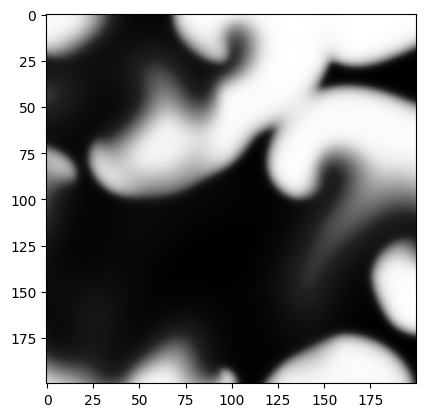

In [254]:
txt=load_buffer(ic_dir).astype(np.float64)
plt.imshow(txt[...,0],cmap='gray')

In [255]:
from lib.measure.get_tips_local import compute_all_spiral_tips

In [256]:
txt=load_buffer(ic_dir).astype(np.float64)
dtxtdt = txt.copy()
all_tips_lst = []
for i in range(int(np.around(niter))):
    get_time_step(txt, dtxtdt)
    txt += dtxtdt*DT
    if i%save_every==0:
        #detect particle number, also.
        all_tips = compute_all_spiral_tips(txt[...,0],
                                           dtxtdt[...,0],
                                           level1=0.4,level2=0,
                                           width=width,height=height)
        #record
        all_tips['t'] = DT * i
        all_tips_lst.append(all_tips)

    

## ^that's the run time

- 12.6 s for 100ms of runtime with recording of tip positions.
    - 11.0 s without recording of tip positions

In [220]:
beep(4)

-n 
-n 
-n 
-n 


0

In [217]:
txt.shape

(200, 200, 3)

In [223]:
#verify particles still exist
print_dict(all_tips)
assert all_tips['n']>0

n=6
x=[2.1942229493392964, 4.200908273254314, 39.11424652696591, 97.42585183059046, 143.12081780826875, 196.5672620770403]
y=[199.02064372416197, 75.2809178963557, 98.85646984542095, 62.232425736942865, 58.65134663128128, 5.175637777340645]
theta=[-9999.0, -9999.0, -9999.0, -9999.0, -9999.0, -9999.0]
grad_ux=[2.9815805866097924, 0.14055238121242708, -2.6161709741663173, 1.018666905468734, 1.091140958188565, 0.9619172038906496]
grad_uy=[0.9780831714918766, 1.0571633730868153, 2.4336021434143125, 0.9711117593892407, 0.7784256741227983, 2.4977703950004555]
grad_vx=[0.005699910147840588, -13.560351123501087, -0.4943204470917485, 2.7250343751113286, 0.7996255370745405, 1.0216432420970678]
grad_vy=[1.0149882345671108, 1.8233490291527759, 1.589738310383666, -1.6806279234130692, 1.4959304119469843, 0.1490185368783013]
v=[0.4105007230761612, 0.4054916026065819, 0.48937795848444354, 0.39873413092635807, 0.40669612341038724, 0.38056208399905167]
dvdt=[-0.0009432128820039971, 0.0006285470913300412

In [225]:
run_time_fk = 12.4/60 #minutes for 100 ms of simulation time with particle detection and recording
# run_time_fk = 1 + 37.8/60 #minutes for 1 second of simulation time with particle detection and recording
# run_time_fk = 17 + 24/60 #minutes #for 25seconds of simulation time
#WJ got 5s in 10 minutes
run_time_fk

0.20666666666666667

# repeat for luo-rudy model

In [262]:
#load poster child csv
# file='/home/timothytyree/Documents/GitHub/care/notebooks/Data/initial-conditions-suite-3-LR/param_qu_tmax_30_Ko_3.8_diffCoef_0.001/trajectories/ic018.21_traj_sr_600_mem_0.csv'
# ic_fn='/home/timothytyree/Documents/GitHub/care/notebooks/Data/initial-conditions-suite-3-LR/ic-out/ic018.21.npz'
# ic_fn=f'{nb_dir}/notebooks/Data/initial-conditions-suite-3-LR/ic-out/ic018.21.npz'
ic_fn=f'{nb_dir}/Data/initial-conditions-suite-3-LR/ic-in/ic018.21.npz'
os.path.exists(ic_fn)

True

In [266]:
txt=load_buffer(ic_fn)
# txt.shape
results_folder=f"{nb_dir}/Data/reaction-range-data"
if not os.path.exists(results_folder):
    os.mkdir(results_folder)
K_o=3.8
diffCoef=0.001
tmin_sec=0.1
#cython accelerated time integration of LR model
from lib.routines.generate_tip_logs_LR_model_cy import *
from lib.routines.kwargs_LR_model_cy import get_kwargs
kwargs = get_kwargs(ic_fn,results_folder=results_folder)
kwargs['tmax']=tmin_sec;print(tmin_sec)
kwargs['diffCoef']=diffCoef
kwargs['K_o']=K_o
txt.shape

0.1


(200, 200, 18)

In [267]:
dt=0.025
dsdpixel=0.025
width=200;height=200
printing=True
dt, one_step_map = get_one_step_map(nb_dir,dt=dt,width=width,height=height,**kwargs)
# dt, one_step_map = get_one_step_map(nb_dir,dt,**kwargs)
# dt, one_step_map = get_one_step_map(nb_dir,dt,dsdpixel,width,height,**kwargs)
# dt, one_step_map = get_one_step_map(nb_dir,dt,**kwargs)
txt_Istim_none=np.zeros(shape=(width,height), dtype=np.float64, order='C')
tmin_early_stopping=tmin_sec*10**3
t=0.
txt=load_buffer(ic_fn).astype('float64')
if printing:
    print(f"integrating to time t={tmin_early_stopping:.3f} ms without recording with dt={dt:.3f} ms.")
    print(f"long run times ~2 minutes expected...")
while (t<tmin_early_stopping):
    one_step_map(txt,txt_Istim_none)
    t+=dt
#precompute anything that needs precomputing
compute_all_spiral_tips= get_compute_all_spiral_tips(mode='simp',width=width,height=height)

integrating to time t=100.000 ms without recording with dt=0.025 ms.
long run times ~2 minutes expected...


In [268]:
level1=-50.
level2=0.
#TODO: track trajectory up to some time at a high time resolution
#check for any tips being present
inVc,outVc,inmhjdfx,outmhjdfx,dVcdt=unstack_txt(txt)
img=inVc[...,0]
dimgdt=dVcdt[...,0]
dict_out=compute_all_spiral_tips(t,img,dimgdt,level1,level2)#,width=width,height=height)
n_tips=dict_out['n']#skip this trial if no spiral tips are present

In [269]:
n_tips

4

In [272]:
for i in range (niter):
    one_step_map(txt,txt_Istim_none)
    t+=dt
    if i%save_every==0:
        #check for any tips being present
        inVc,outVc,inmhjdfx,outmhjdfx,dVcdt=unstack_txt(txt)
        img=inVc[...,0]
        dimgdt=dVcdt[...,0]
        dict_out=compute_all_spiral_tips(t,img,dimgdt,level1,level2)#,width=width,height=height)
        n_tips=dict_out['n']#skip this trial if no spiral tips are present
    

In [ ]:
run_time_lr = 31.4/60 #minutes

In [273]:
n_tips

6

# generating off topic data from records of the full models

In [5]:
# printing=True
# use_save_df_to_parquet_by=True
# use_save_df_to_parquet_by=False
# #load fortranic tip positions
# nb_dir_ = '/Users/timothytyree/Documents/GitHub/care/notebooks'
# folder=f"{nb_dir_}/Data/from_wjr/positions_fk/200x200"
# fn = 'tippos_per_c_001'
# folder=f"{nb_dir_}/Data/from_wjr/positions_lr/200x200"
# fn = 'tippos_per_001'
# input_dir = os.path.join(folder,fn)
# log_folder_parquet=f'{folder}/positions'
# assert os.path.exists(input_dir)
# if use_save_df_to_parquet_by:
#     df_log=parse_fortranic_tip_pos(input_dir)
#     #partition df_log into a folder of tip logs
#     save_df_to_parquet_by(df_log,log_folder_parquet,by='trial_num',compression='snappy',index=None)
#     print(f"saved to spiral tip positions to {log_folder_parquet=}")
#     #determine width and height of the computational domain input the discretization
#     width,height=df_log.describe().loc['max'][['x','y']].values.T
#     del df_log
# else:
#     width=200
#     height=200

In [34]:
# N0=2
# t_lst=[]
# nv_lst=[]
# for fn in os.listdir(log_folder_parquet):
#     try:
#         trial_num = eval(fn.split('=')[1])
#         # load tip position data
#         g=load_parquet_by_trial_num(trial_num=trial_num,folder_parquet=log_folder_parquet)
#         n_series = g.groupby(by='t')['n'].min()
#         t0_values = n_series[n_series==N0].index.values
#         tf = n_series.index.values.max()
#         t_values = tf-t0_values
#         #record
#         t_lst.extend(t_values)
#         nv = g.groupby('t')['n'].mean()[::1000] #once every 1s
#         nv = nv[nv%2==0]
#         nv_lst.extend(nv)
#     except IndexError as e:
#         pass
#         #print(f"IndexError for {fn}: {e}")
# n_series.max()

14

In [6]:
# plt.hist(nv_lst,density=True,bins=100)
# plt.show()

In [7]:
# #print summary stats for distribution of particle numbers
# nv_values = np.array(nv_lst)
# meann,Delta_meann,num_obs,p_normal=comp_mean_bootstrap_uncertainty(nv_values)
# print(f"{meann=},{Delta_meann=},{num_obs=},{p_normal=}")
# median = np.median(nv_values)
# q25 = np.quantile(nv_values,0.25)
# q75 = np.quantile(nv_values,0.75)
# print(f"median: {median} (IQR: {q25}-{q75}, N={nv_values.shape[0]})")

In [8]:
# #find corresponding data from the particle model
# # nb_dir.split('/')
# '/Users/timothytyree/Documents/GitHub/bgmc/python/data/'
# nb_dir

In [9]:
# # !conda env list
# import sys
# print(sys.executable)